# Movie Recommender - Preprocessing Pipeline

Notebook này chuyển đổi quy trình tiền xử lý dữ liệu từ các file script `.py` sang dạng interactive để dễ dàng theo dõi và trực quan hóa kết quả.

In [12]:
import os
import ast
import json
import re
from pathlib import Path
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, MultiLabelBinarizer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Thiết lập đường dẫn
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"
CLEANED_DIR = DATA_DIR / "cleaned"
OUTPUT_DIR = ROOT_DIR / "outputs"
ENCODERS_DIR = OUTPUT_DIR / "encoders"

CLEANED_DIR.mkdir(parents=True, exist_ok=True)
ENCODERS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data Cleaning (cleaning.py)

Làm sạch các tập dữ liệu thô (Trakt và TMDB), chuẩn hóa cột và xử lý các giá trị không hợp lệ.

In [13]:
@dataclass
class CleaningStats:
    rows_before: int
    rows_after: int
    dropped_exact_duplicates: int
    dropped_missing_core_fields: int

COMMON_SCHEMA_COLUMNS = [
    "user_id", "movie_id", "movie_title", "rating", "genres",
    "cast", "release_year", "language", "release_year_clean",
    "genres_list", "primary_genre", "genre_count",
]

def _canonicalize_genre_name(name: str) -> str:
    normalized = name.strip().lower().replace("_", " ").replace("-", " ")
    normalized = re.sub(r"\s+", " ", normalized)
    alias_map = {
        "sci fi": "science fiction",
        "sci fi fantasy": "science fiction",
        "science fiction": "science fiction",
    }
    return alias_map.get(normalized, normalized)

def parse_genres(value: Any) -> list[str]:
    if isinstance(value, (list, tuple, set)):
        return [
            _canonicalize_genre_name(str(item["name"])) if isinstance(item, dict) else _canonicalize_genre_name(str(item))
            for item in value if item
        ]
    if isinstance(value, dict) and value.get("name"):
        return [_canonicalize_genre_name(str(value["name"]))]
    if pd.isna(value):
        return []
    raw = str(value).strip()
    if not raw: return []
    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(raw)
            if isinstance(parsed, list):
                return [
                    _canonicalize_genre_name(str(item["name"])) if isinstance(item, dict) else _canonicalize_genre_name(str(item))
                    for item in parsed if item
                ]
        except: pass
    parts = re.split(r"[,|;/]", raw)
    return [_canonicalize_genre_name(p.strip()) for p in parts if p.strip()]

def normalize_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)
    return df

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    for col in ["rating", "vote_average", "vote_count"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "release_year" in df.columns:
        year_num = pd.to_numeric(df["release_year"], errors="coerce")
        year_num = year_num.where(year_num.between(1870, 2100), np.nan)
        year_parse = pd.to_datetime(df["release_year"], errors="coerce")
        df["release_year_clean"] = year_num.fillna(year_parse.dt.year).astype("Int64")
    if "language" in df.columns:
        df["language"] = df["language"].str.lower()
    if "genres" in df.columns:
        df["genres_list"] = df["genres"].apply(parse_genres)
        df["primary_genre"] = df["genres_list"].apply(lambda x: x[0] if x else None)
        df["genre_count"] = df["genres_list"].apply(len)
    return df

def harmonize_schema(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "cast_names" in df.columns:
        df = df.rename(columns={"cast_names": "cast"})
    for col in COMMON_SCHEMA_COLUMNS:
        if col not in df.columns: df[col] = pd.NA
    return df[COMMON_SCHEMA_COLUMNS].copy()

def clean_dataset(df: pd.DataFrame) -> tuple[pd.DataFrame, CleaningStats]:
    df = normalize_text_columns(df.copy())
    df = standardize_columns(df)
    df = harmonize_schema(df)
    rows_before = len(df)
    temp = df.copy()
    for col in temp.columns:
        if temp[col].apply(lambda x: isinstance(x, (list, dict, set))).any():
            temp[col] = temp[col].apply(lambda x: json.dumps(x, sort_keys=True))
    df = df.loc[~temp.duplicated()].copy()
    after_exact = len(df)
    df = df.drop_duplicates(subset=["user_id", "movie_id"], keep="last")
    required = ["user_id", "movie_id", "rating", "genres", "cast"]
    df = df.dropna(subset=[c for c in required if c in df.columns])
    df = df[df["genres_list"].map(len) > 0]
    if "language" in df.columns:
        df = df[df["language"] == "en"]
    stats = CleaningStats(
        rows_before=rows_before, rows_after=len(df),
        dropped_exact_duplicates=rows_before - after_exact,
        dropped_missing_core_fields=after_exact - len(df)
    )
    return df, stats

def adjust_half_step_ratings(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rating = pd.to_numeric(df["rating"], errors="coerce")
    frac = rating - np.floor(rating)
    mask = np.isclose(frac, 0.5)
    df.loc[mask, "rating"] = rating.loc[mask] + 0.5
    return df

In [14]:
print("⏳ Đang xử lý Trakt dataset...")
df_trakt = pd.read_csv(DATA_DIR / "trakt_ultimate_checkpoint.csv")
cleaned_trakt, stats_trakt = clean_dataset(df_trakt)
cleaned_trakt = adjust_half_step_ratings(cleaned_trakt)

print("⏳ Đang xử lý TMDB dataset...")
df_movie = pd.read_csv(DATA_DIR / "movie_final_dataset.csv")
cleaned_movie, stats_movie = clean_dataset(df_movie)
cleaned_movie = adjust_half_step_ratings(cleaned_movie)

cleaned_trakt.to_csv(CLEANED_DIR / "Trakt_cleaned.csv", index=False)
cleaned_movie.to_csv(CLEANED_DIR / "TMDB_cleaned.csv", index=False)
print("✅ Đã làm sạch và lưu 2 tập dữ liệu.")

⏳ Đang xử lý Trakt dataset...


C:\Users\haiau\AppData\Local\Temp\ipykernel_5212\695069139.py:49: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


⏳ Đang xử lý TMDB dataset...


C:\Users\haiau\AppData\Local\Temp\ipykernel_5212\695069139.py:49: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


✅ Đã làm sạch và lưu 2 tập dữ liệu.


## 2. Data Integration (integration.py)

Hợp nhất các tập dữ liệu đã làm sạch thành một tập duy nhất.

In [15]:
def integrate_datasets(movie_path, trakt_path, output_path):
    d1 = pd.read_csv(movie_path)
    d2 = pd.read_csv(trakt_path)
    d1["source"] = "TMDB_cleaned"
    d2["source"] = "Trakt_cleaned"
    
    merged = pd.concat([d1, d2], ignore_index=True)
    before = len(merged)
    merged = merged.drop_duplicates()
    after_exact = len(merged)
    
    key_cols = [c for c in ["user_id", "movie_id", "rating"] if c in merged.columns]
    if key_cols: 
        merged = merged.drop_duplicates(subset=key_cols, keep="first")
    after_key = len(merged)
    
    merged.to_csv(output_path, index=False)
    return merged, {"before": before, "after": after_key}

merged_df, int_stats = integrate_datasets(
    CLEANED_DIR / "TMDB_cleaned.csv", 
    CLEANED_DIR / "Trakt_cleaned.csv", 
    CLEANED_DIR / "integrated_dataset_cleaned.csv"
)
print(f"✅ Đã tích hợp dữ liệu. Kích thước cuối cùng: {merged_df.shape}")

✅ Đã tích hợp dữ liệu. Kích thước cuối cùng: (10411, 13)


### Trực quan hóa bước Cleaning & Integration

Tạo các biểu đồ phân phối nguồn dữ liệu và so sánh số lượng bản ghi.

💾 Đã lưu biểu đồ: source_distribution.png


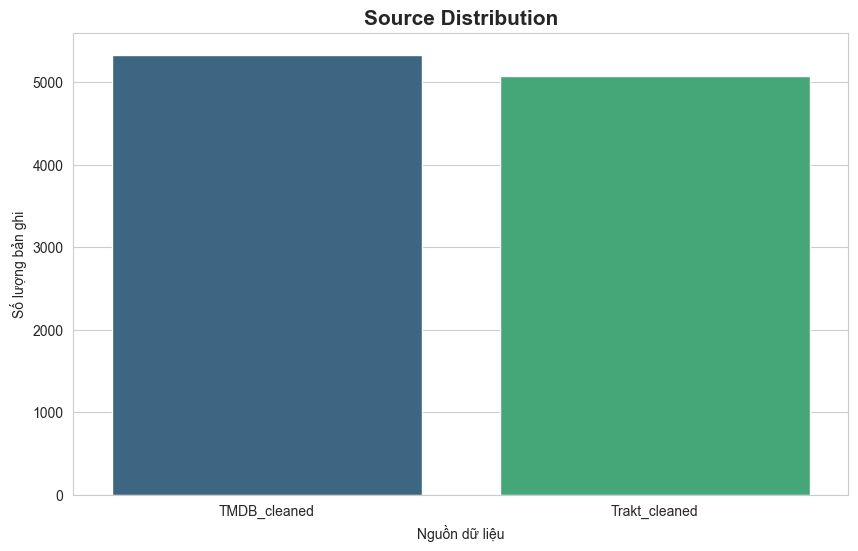

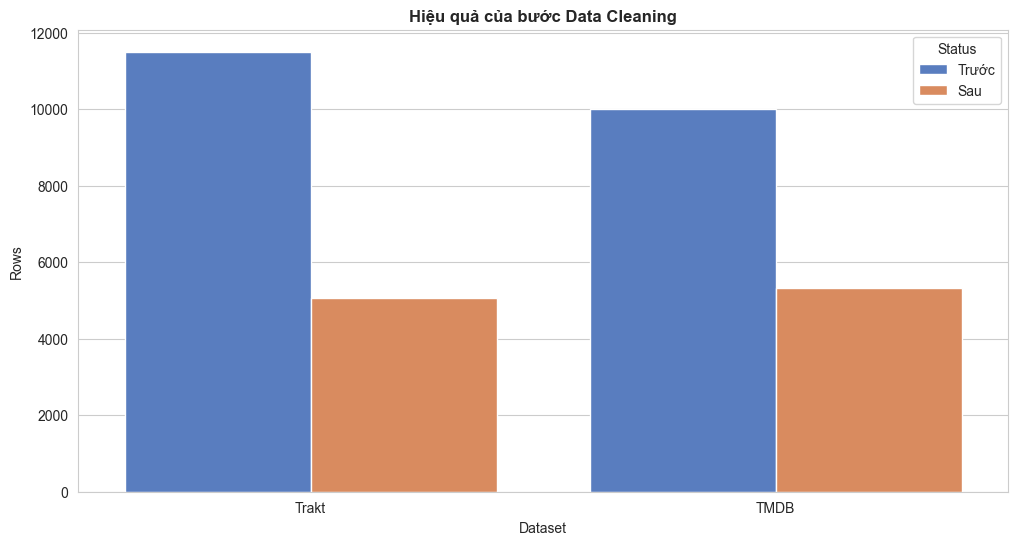

In [16]:
# Tạo thư mục lưu trữ ảnh trực quan hóa
VIS_DIR = OUTPUT_DIR / "visualizations" / "preprocessing"
VIS_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(filename):
    plt.savefig(VIS_DIR / filename, dpi=300, bbox_inches='tight')
    print(f"💾 Đã lưu biểu đồ: {filename}")

# 1. Source Distribution
plt.figure(figsize=(10, 6))
source_counts = merged_df['source'].value_counts()
sns.barplot(x=source_counts.index, y=source_counts.values, palette='viridis', hue=source_counts.index, legend=False)
plt.title('Source Distribution', fontweight='bold', fontsize=15)
plt.ylabel('Số lượng bản ghi')
plt.xlabel('Nguồn dữ liệu')
save_plot('source_distribution.png')
plt.show()

# So sánh Before/After Cleaning
data = {
    'Dataset': ['Trakt', 'Trakt', 'TMDB', 'TMDB'],
    'Status': ['Trước', 'Sau', 'Trước', 'Sau'],
    'Rows': [stats_trakt.rows_before, stats_trakt.rows_after, stats_movie.rows_before, stats_movie.rows_after]
}
sns.barplot(x='Dataset', y='Rows', hue='Status', data=pd.DataFrame(data), palette='muted')
plt.title('Hiệu quả của bước Data Cleaning', fontweight='bold')
plt.show()

## 3. Data Transformation (transform.py)

Xử lý các cột bị thiếu, đồng nhất các trường và tái cấu trúc thông tin thể loại.

In [17]:
def _drop_identical_columns(df: pd.DataFrame) -> pd.DataFrame:
    keep_cols, drop_cols = [], []
    for col in df.columns:
        matched = False
        cur = df[col]
        for kept in keep_cols:
            base = df[kept]
            equal_mask = (cur == base) | (cur.isna() & base.isna())
            if bool(equal_mask.all()):
                drop_cols.append(col)
                matched = True; break
        if not matched: keep_cols.append(col)
    return df.drop(columns=drop_cols) if drop_cols else df

def _consolidate_fields(df: pd.DataFrame) -> pd.DataFrame:
    consolidated = df.copy()
    if "release_year_clean" in consolidated.columns:
        cleaned = pd.to_numeric(consolidated["release_year_clean"], errors="coerce")
        if "release_year" in consolidated.columns:
            original = pd.to_numeric(consolidated["release_year"], errors="coerce")
            consolidated["release_year"] = original.fillna(cleaned)
        else: consolidated["release_year"] = cleaned
        consolidated = consolidated.drop(columns=["release_year_clean"])
    if "genres_list" in consolidated.columns and "genres" in consolidated.columns:
        consolidated = consolidated.drop(columns=["genres"])
    return _drop_identical_columns(consolidated)

def transform_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    for col in ["cast", "genres"]:
        if col not in df.columns: continue
        s = df[col].astype("string").fillna("unknown")
        df[col] = s.mask(s.str.strip().eq(""), "unknown")
    if "genres" in df.columns:
        gl = df["genres"].apply(parse_genres)
        df["genres_list"] = gl.apply(lambda g: json.dumps(g))
        df["primary_genre"] = gl.apply(lambda g: g[0] if g else "unknown")
        df["genre_count"] = gl.apply(len)
    df = _consolidate_fields(df)
    df.to_csv(path, index=False)
    return df

transformed_df = transform_dataset(CLEANED_DIR / "integrated_dataset_cleaned.csv")
print(f"✅ Đã biến đổi dữ liệu. Hình dạng: {transformed_df.shape}")

✅ Đã biến đổi dữ liệu. Hình dạng: (10411, 11)


### Trực quan hóa Biến đổi dữ liệu (Genre & Rating)

Phân tích phân phối điểm đánh giá và thể loại sau khi biến đổi.

💾 Đã lưu biểu đồ: rating_distribution.png


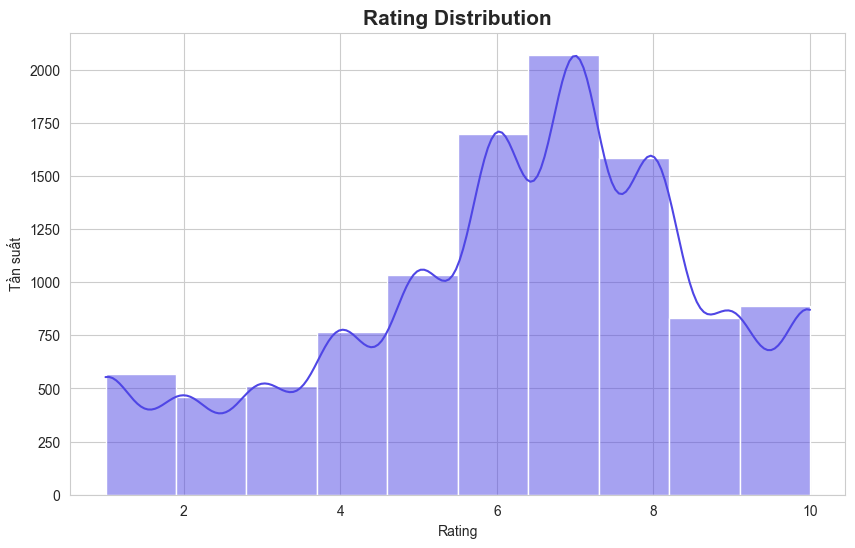

💾 Đã lưu biểu đồ: genre_distribution_after_preprocessing.png


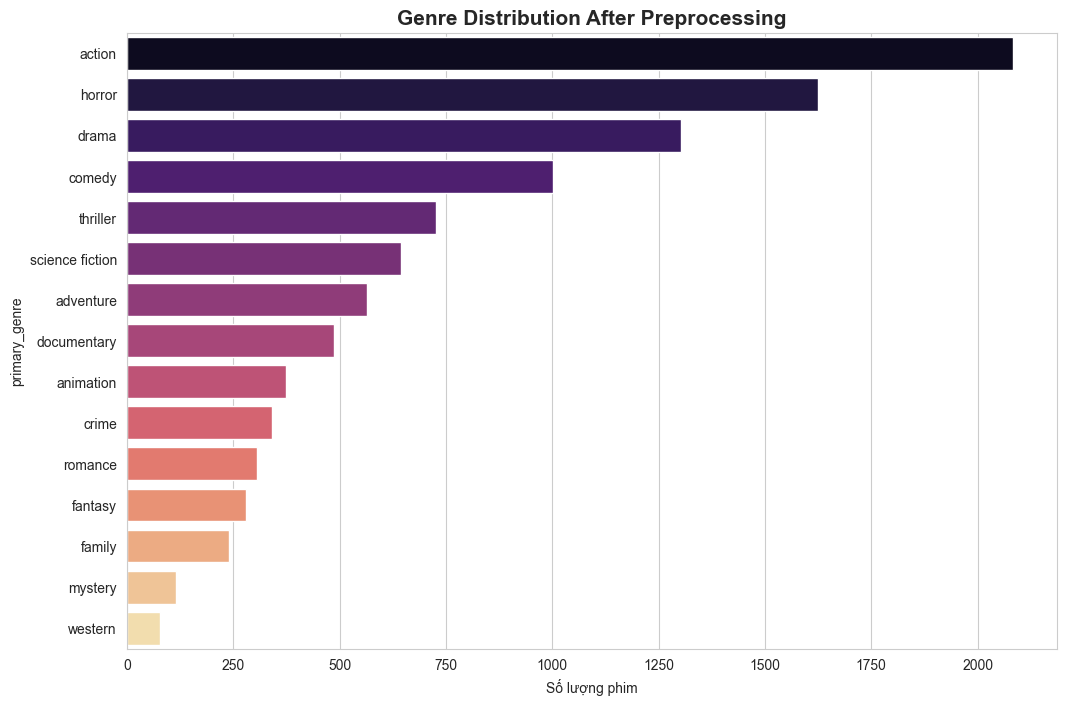

💾 Đã lưu biểu đồ: genre_count_distribution.png


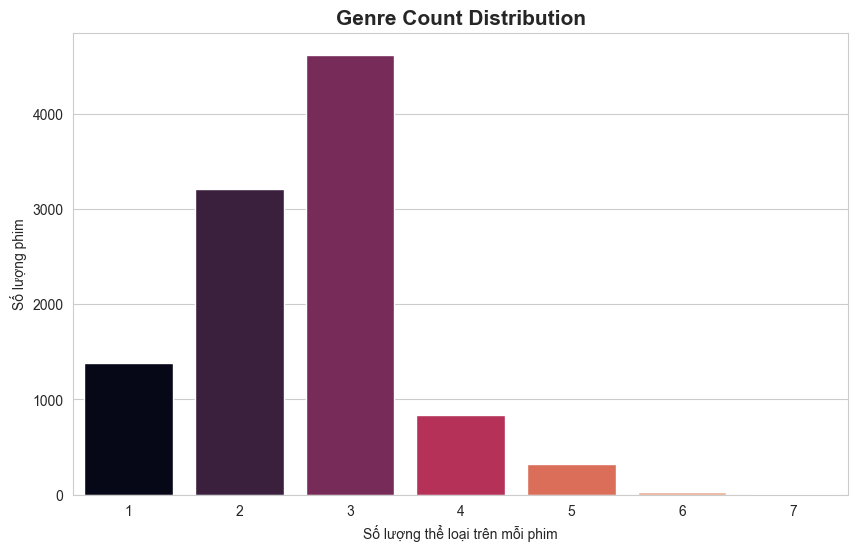

In [18]:
# 2. Rating Distribution
plt.figure(figsize=(10, 6))
sns.histplot(transformed_df['rating'], bins=10, kde=True, color='#4f46e5')
plt.title('Rating Distribution', fontweight='bold', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Tần suất')
save_plot('rating_distribution.png')
plt.show()

# 3. Genre Distribution After Preprocessing
plt.figure(figsize=(12, 8))
top_genres = transformed_df['primary_genre'].value_counts().head(15)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma', hue=top_genres.index, legend=False)
plt.title('Genre Distribution After Preprocessing', fontweight='bold', fontsize=15)
plt.xlabel('Số lượng phim')
save_plot('genre_distribution_after_preprocessing.png')
plt.show()

# 4. Genre Count Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=transformed_df, x='genre_count', palette='rocket', hue='genre_count', legend=False)
plt.title('Genre Count Distribution', fontweight='bold', fontsize=15)
plt.xlabel('Số lượng thể loại trên mỗi phim')
plt.ylabel('Số lượng phim')
save_plot('genre_count_distribution.png')
plt.show()

## 4. Feature Encoding (encoding.py)

Mã hóa các đặc trưng thành dạng số để đưa vào mô hình máy học.

In [19]:
def preprocess_features(df: pd.DataFrame):
    df = df.copy()
    df["genres_list_parsed"] = df["genres_list"].apply(lambda x: json.loads(x) if pd.notna(x) else [])
    df["cast"] = df["cast"].fillna("unknown")

    # Scalers
    scaler_rating = MinMaxScaler()
    df["rating_scaled"] = scaler_rating.fit_transform(df[["rating"]])
    joblib.dump(scaler_rating, ENCODERS_DIR / "minmax_scaler_rating.pkl")

    # Multi-Label Binarizer for genres
    mlb = MultiLabelBinarizer()
    genre_matrix = mlb.fit_transform(df["genres_list_parsed"])
    genre_cols = [f"genre_{g.replace(' ', '_')}" for g in mlb.classes_]
    genre_df = pd.DataFrame(genre_matrix, columns=genre_cols, index=df.index)
    df = pd.concat([df, genre_df], axis=1)
    joblib.dump(mlb, ENCODERS_DIR / "multilabel_binarizer_genres.pkl")

    # Label Encoders
    le_genre = LabelEncoder()
    df["primary_genre_encoded"] = le_genre.fit_transform(df["primary_genre"].fillna("unknown"))
    joblib.dump(le_genre, ENCODERS_DIR / "label_encoder_primary_genre.pkl")

    le_user = LabelEncoder()
    df["user_idx"] = le_user.fit_transform(df["user_id"].astype(str))
    joblib.dump(le_user, ENCODERS_DIR / "label_encoder_user.pkl")

    le_movie = LabelEncoder()
    df["movie_idx"] = le_movie.fit_transform(df["movie_id"].astype(str))
    joblib.dump(le_movie, ENCODERS_DIR / "label_encoder_movie.pkl")

    # TF-IDF for cast
    tfidf_cast = TfidfVectorizer(max_features=500, token_pattern=r"[^,]+")
    cast_matrix = tfidf_cast.fit_transform(df["cast"])
    joblib.dump(tfidf_cast, ENCODERS_DIR / "tfidf_cast_vectorizer.pkl")

    # Other meta
    df["source_encoded"] = df["source"].map({"TMDB_cleaned": 0, "Trakt_cleaned": 1})
    scaler_meta = MinMaxScaler()
    df[["year_scaled", "genre_count_scaled"]] = scaler_meta.fit_transform(
        df[["release_year", "genre_count"]].fillna(0)
    )
    joblib.dump(scaler_meta, ENCODERS_DIR / "minmax_scaler_meta.pkl")

    return df.drop(columns=["genres_list_parsed"]), cast_matrix

final_df, cast_tfidf = preprocess_features(transformed_df)
final_df.to_csv(CLEANED_DIR / "integrated_dataset_encoded.csv", index=False)
sp.save_npz(ENCODERS_DIR / "cast_tfidf_matrix.npz", cast_tfidf)
print(f"✅ Đã hoàn tất Encoding. Kích thước tập dữ liệu cuối: {final_df.shape}")

✅ Đã hoàn tất Encoding. Kích thước tập dữ liệu cuối: (10411, 42)


### Ma trận tương quan (Correlation Heatmap)

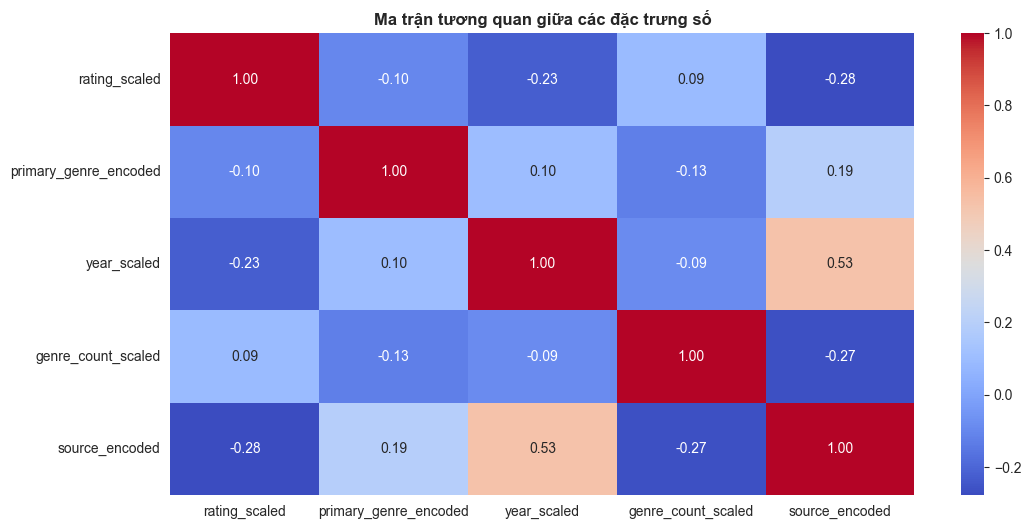

In [20]:
numeric_cols = ['rating_scaled', 'primary_genre_encoded', 'year_scaled', 'genre_count_scaled', 'source_encoded']
corr = final_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các đặc trưng số', fontweight='bold')
plt.show()

In [21]:
print("🚀 Hoàn tất Pipeline Tiền xử lý!")
final_df.head()

🚀 Hoàn tất Pipeline Tiền xử lý!


,user_id,movie_id,movie_title,rating,cast,release_year,language,genres_list,primary_genre,genre_count,...,genre_thriller,genre_tv_movie,genre_war,genre_western,primary_genre_encoded,user_idx,movie_idx,source_encoded,year_scaled,genre_count_scaled
0,Sejian,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,779,741,0,1.0,0.333333
1,MovieGuys,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,600,741,0,1.0,0.333333
2,Dean,1265609,War Machine,9.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,248,741,0,1.0,0.333333
3,CinemaSerf,1290821,Shelter,6.0,"Jason Statham, Bodhi Rae Breathnach, Michael S...",2026,en,"[""action"", ""crime"", ""thriller""]",action,3,...,1,0,0,0,0,183,797,0,1.0,0.333333
4,MovieGuys,1290821,Shelter,6.0,"Jason Statham, Bodhi Rae Breathnach, Michael S...",2026,en,"[""action"", ""crime"", ""thriller""]",action,3,...,1,0,0,0,0,600,797,0,1.0,0.333333
